# 🐜 __Ant Colony Foraging Simulation__

<details><summary style="color:rgb(21, 233, 162)"><b>Conceptual Analysis: Emergent Complexity vs. Stigmergy <i style="color:orange">(Click to Expand)</i></b></summary>



## What This Simulation Shows

This is a model of **ant foraging behavior** using simple rules to solve an optimization problem: **which food sources should a colony prioritize?** The simulation compares three strategies: **Ant Colony with pheromones** (reinforcement learning), **Random Exploration** (no memory), and **Ideal allocation** (omniscient baseline).

### 🔬 Simulation Architecture:

**Environment:**
- **10 food sources** randomly placed in a 40×40 grid around the nest at (0,0)
- Each source has 4 attributes:
  - **Distance** from nest (normalized, closer = better)
  - **Quality** (1-10 scale, nutritional value)
  - **Quantity** (100-1000 units of food)
  - **Ease of Access** (1-10 scale, terrain/predator difficulty)
- **Food Score** calculated from weighted attributes: `distance×0.4 + quality×0.225 + quantity×0.225 + ease×0.15`

**Ant Behavior:**
- **Scout frequency**: Every 12th ant explores randomly (8.3% scouts, 91.7% followers)
- **Perception range**: ±3° angular detection radius for food sources
- **Pheromone deposit**: Non-linear scaling based on food score
  - Low scores (≤0.54): **penalized** with power curve (bad sources become less attractive)
  - High scores (≥0.66): **amplified** with power curve (good sources become MUCH more attractive)
  - Creates 10-40× visit amplification for high-value sources
- **Evaporation**: Pheromones decay by 35% every 8 ant iterations
- **Dynamic adaptation**: When food depletes, pheromones naturally fade and colony shifts to new sources

**Key Parameters:**
- `ANTS = 10000` total iterations
- `scout_iter = 12` (scout frequency)
- `evap_iter = 8` (evaporation frequency)
- `evaporation_rate = 0.35` (35% decay per evaporation cycle)
- `ANT_PERCEPTION = 3` degrees (angular detection radius)
- `negligible_pheromone_threshold = 0.05` (minimum pheromone to follow)

### 🎯 Three Methods Compared:

1. **Ant Colony (Pheromones)**: Scouts explore randomly, successful foragers deposit pheromones proportional to food value, followers prioritize strongest trails, pheromones evaporate over time
2. **Random Exploration**: Pure random search with no memory or coordination (baseline for emergence)
3. **Ideal Allocation**: Omniscient strategy that visits each source exactly proportional to its food quantity (impossible for real ants, but provides theoretical upper bound)

### What Emerges:

- ✅ **Collective convergence** on better food sources (10-40× more visits to high-value sources)
- ✅ **Adaptive resource allocation** without central planning
- ✅ **Dynamic reoptimization** when food depletes (pheromone decay enables discovery of new sources)
- ✅ **Distributed memory** via pheromone trails (environmental stigmergy)
- ✅ **Efficiency gains**: Ant colony achieves 20-40% better allocation efficiency than random exploration

<i style="color:orange">**One ant with a notebook could achieve the same result by making 10,000 sequential trips.**</i>

### What This <i style="color:rgb(16, 225, 24)">__IS__</i>:

- ✅ **[Stigmergy:](https://www.allaboutai.com/ai-glossary-stigmergy/)** Communication through environmental modification (pheromone trails)
- ✅ **Reinforcement learning**: Statistical optimization through weighted feedback loops
- ✅ **Exploration vs. exploitation**: Balancing discovery (scouts) with leveraging known information (followers)
- ✅ **Bio-inspired algorithm**: Real ants use similar pheromone-based foraging strategies
- ✅ **Parallel speedup**: Swarm processes information faster than sequential search

### What this is <i style="color:red">__NOT__</i>:

Ant Colony Optimization and similar swarm algorithms are frequently presented as examples of **emergent complexity**, where simple individual rules create sophisticated collective behavior that seems "intelligent." However, this framing deserves skepticism. The core issue: **one ant with memory could achieve identical results through sequential learning**. What appears to be collective intelligence is really just distributed reinforcement learning, thus better options get reinforced through feedback loops.

This aligns with Mark Bedau's distinction between *[weak emergence](https://en.wikipedia.org/wiki/Emergence#Weak_emergence)* (behavior derivable from components but computationally complex) and *[strong emergence](https://en.wikipedia.org/wiki/Emergence#Strong_emergence)* (genuinely new properties impossible to predict from components). ACO exhibits weak emergence at best, the outcomes are in principle predictable and one agent could achieve them, just slower. See also critiques of *[swarm fetishism](https://www.ribbonfarm.com/2010/07/26/a-big-little-idea-called-legibility/)* in popular science literature that anthropomorphizes distributed algorithms.

- ❌ **True emergence**: No new capabilities that one agent couldn't achieve alone
- ❌ **Collective intelligence**: Just shared memory, not genuine cooperation
- ❌ **Complex self-organization**: No spatial patterns, traffic flows, or novel structures emerge

---

### 📊 What Gets Measured:

The simulation tracks **allocation efficiency**: How well do visit percentages match food quantity percentages?
- **Perfect efficiency (100%)**: Visits exactly proportional to food quantities (impossible without omniscience)
- **Ant colony**: Typically achieves close to 90% efficiency through pheromone reinforcement
- **Random exploration**: Typically achieves very low efficiency (treats all sources equally, wastes effort on low-value sources)

Even though this isn't "magic emergence," it demonstrates:

1. **Simple rules → sophisticated optimization**: No ant needs complex algorithms or global knowledge
2. **Decentralized coordination**: No central controller allocates resources
3. **Robustness**: System continues working if individual ants fail
4. **Quantifiable intelligence**: Measurable improvement over random baseline

<br>

<div align="center">🐜🐜🐜🐜🐜 ⟵ 🏠 ⟶ 🐜🐜🐜🐜🐜</div>


---

</details>

<hr style="color:blue; background-color:blue;height:3px"></hr>

# 🐜 Interactive Demo

This notebook demonstrates how to use the `AntColonySimulation` class with custom parameters.

**Three Methods Compared:**
1. **Ant Colony (Pheromones)** - Emergent intelligence through stigmergy
2. **Random Exploration** - No memory baseline
3. **Ideal Allocation** - Theoretical optimal (omniscient)

---

## 📦 Import the Simulation Class

In [1]:
from ant_colony_simulation import AntColonySimulation
from IPython.display import display, HTML, Markdown

print("✅ AntColony Simulation class loaded successfully.")

✅ AntColony Simulation class loaded successfully.


## ⚙️ Configure Simulation Parameters

**Modify any parameter below to customize the simulation.**


<details>
<summary style="color:rgb(21, 233, 162); background-color:rgb(17, 0, 0); padding:5px"><b>📖 Understanding Key Parameters. <i style="color:orange">(Click to Expand)</i></b></summary>

<br>

**Pheromone Deposit Exponents:**

The exponent parameters control how dramatically pheromone deposits change based on food source quality:

- **`penalty_exponent`** (default: 1.5): Controls penalty curve for low-quality sources
  - Higher values = steeper penalties for poor sources
  - Lower values = gentler penalties
  
- **`reward_exponent`** (default: 0.4): Controls reward curve for high-quality sources
  - Higher values = steeper rewards for excellent sources
  - Lower values = more gradual rewards
  
These create a non-linear feedback system where great sources get amplified and poor sources get suppressed.

</details>

In [3]:
# 🎛️ CONFIGURATION DICTIONARY - Edit these values to customize the simulation
config = {
    
    # ===== ANT BEHAVIOR PARAMETERS =====
    'ant_perception': 3,                  # Default: 3 - Angular food detection radius (degrees)
    'max_ants': 10000,                    # Default: 10000 - Maximum iterations for ant colony
    'scout_frequency': 12,                # Default: 12 - Every Nth ant scouts randomly (8.3% scouts)
    'evaporation_frequency': 8,           # Default: 8 - Evaporation every N iterations
    'evaporation_rate': 0.35,             # Default: 0.35 - Pheromone decay rate (0-1), 35% per evaporation frequency cycle
    
    # ===== PHEROMONE DEPOSIT PARAMETERS =====
    'pheromone_midpoint': 0.6,            # Default: 0.6 - Threshold between penalty and reward
    'pheromone_range': 0.06,              # Default: 0.06 - Neutral zone around midpoint
    'penalty_exponent': 1.5,              # Default: 1.5 - Low score penalty power curve
    'penalty_multiplier': 0.75,           # Default: 0.75 - Low score penalty scale factor
    'reward_exponent': 0.4,               # Default: 0.4 - High score reward power curve
    'reward_multiplier': 1.85,            # Default: 1.85 - High score reward scale factor
    
    # ===== FOOD SCORE WEIGHTS =====
    'weight_distance': 0.4,               # Default: 0.4 - Distance importance (40%)
    'weight_quality': 0.225,              # Default: 0.225 - Quality importance (22.5%)
    'weight_quantity': 0.225,             # Default: 0.225 - Quantity importance (22.5%)
    'weight_ease': 0.15,                  # Default: 0.15 - Ease of access importance (15%)
    
          } 
 
display(Markdown("✅ **Configuration loaded!**"))
display(Markdown('💡 **To use default parameters instead:** Set <span style="color:black; padding:5px; font-family:courier; border-radius:5px; background-color:rgb(85,185,185)">config=None</span> (or omit it entirely) in the initialization cell below.'))

✅ **Configuration loaded!**

💡 **To use default parameters instead:** Set <span style="color:black; padding:5px; font-family:courier; border-radius:5px; background-color:rgb(85,185,185)">config=None</span> (or omit it entirely) in the initialization cell below.

<hr style="color:blue; background-color:blue;height:3px"></hr>

## <summary>🎬 Initialize Simulation</summary>

__Create the simulation with your config and initialize the environment__.

<details>

<summary style="color:rgb(21, 233, 162); background-color:rgb(14, 1, 1); padding:5px"><b>🌱 Purpose of the Seed parameter. <i style="color:orange">(Click to Expand)</i></b></summary>

- Using a seed (e.g., `seed=42`) makes the environment reproducible
- Same seed = same food source locations, quantities, and qualities every time
- Great for testing different ant behaviors on identical environments
- Omit seed for random environments each run

</details>

In [4]:
# Create simulation with custom config
sim = AntColonySimulation(config=None)

# Initialize environment (optional: add seed for reproducibility)
sim.initialize_environment(seed=None)

# Display environment summary
print(sim.get_environment_summary())

🐜 FOOD SOURCES INITIALIZED:

ID   Location        Dist    Angle   Quality   Quantity   Ease   Patch-Size Score 
F1   (0, -32)        32.00   270.00  9         436        5      2.1        0.63  
F2   (23, -28)       36.24   309.40  9         101        8      1.0        0.56  
F3   (23, 20)        30.48   41.01   8         311        9      1.8        0.65  
F4   (-30, -18)      34.99   210.96  5         690        7      2.6        0.60  
F5   (-19, 6)        19.92   162.47  6         376        1      1.9        0.56  
F6   (8, 9)          12.04   48.37   2         344        6      1.9        0.59  
F7   (4, -28)        28.28   278.13  10        382        7      2.0        0.70  
F8   (-24, 14)       27.78   149.74  7         398        8      2.0        0.65  
F9   (13, 18)        22.20   54.16   4         141        3      1.2        0.47  
F10  (16, 34)        37.58   64.80   10        236        1      1.5        0.50  

✅ Environment ready for simulation!


## 🗺️ Visualize Environment

<strong style="color: orange;">Optional for visualization purposes only.</strong>

__See the nest and food source locations before running the simulation__.

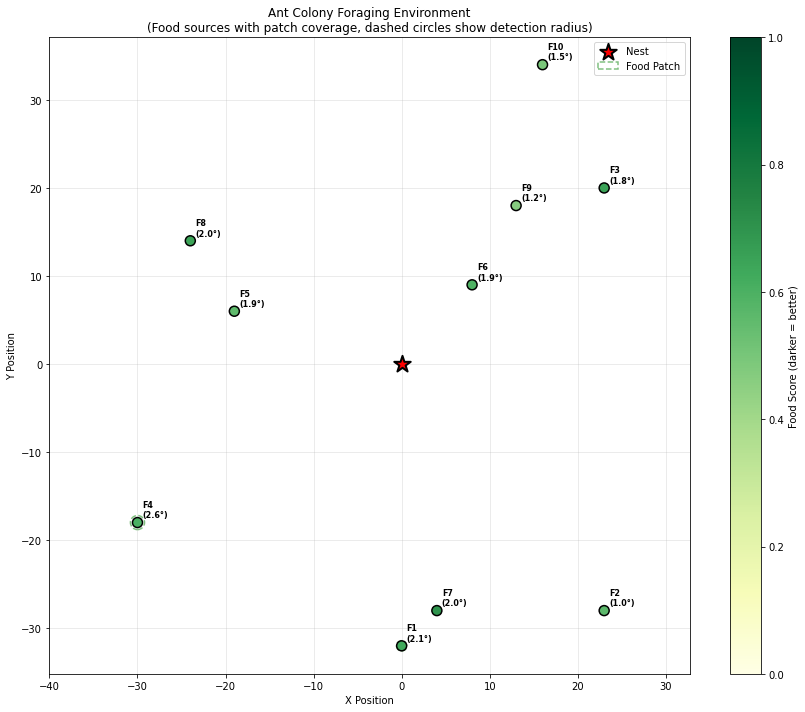

In [5]:
sim.visualize_environment(figsize=(12, 10))

## 🐜 Run Ant Colony Simulation

Run the pheromone-based foraging simulation.

In [6]:
# Run ant colony simulation (set verbose=True to see progress)
ant_results = sim.run_ant_colony_simulation(verbose=True)

print(f"\n📊 Ant Colony Results:")
print(f"  • Total visits: {sum(ant_results['paths']):,}")
print(f"  • Iterations: {ant_results['iterations']:,}")
print(f"  • Visits per source: {ant_results['paths']}")

Starting Ant Colony Simulation...
Starting Food Supply: 3415

Ant Iteration: 200
Paths: [0, 0, 0, 183, 1, 0, 0, 0, 0, 0]
Quantity: [436, 101, 311, 507, 375, 344, 382, 398, 141, 236]
Pheromone Levels: [0.0, 0.0, 0.0, 11.54, 0.01, 0.0, 0.0, 0.0, 0.0, 0.0]
Remaining: 3231

Ant Iteration: 400
Paths: [0, 0, 0, 367, 3, 1, 0, 0, 0, 2]
Quantity: [436, 101, 311, 323, 373, 343, 382, 398, 141, 234]
Pheromone Levels: [0.0, 0.0, 0.0, 5.52, 0.24, 0.0, 0.0, 0.0, 0.0, 0.01]
Remaining: 3042

Ant Iteration: 600
Paths: [0, 0, 0, 552, 6, 1, 0, 0, 0, 2]
Quantity: [436, 101, 311, 138, 370, 343, 382, 398, 141, 234]
Pheromone Levels: [0.0, 0.0, 0.0, 4.98, 0.11, 0.0, 0.0, 0.0, 0.0, 0.0]
Remaining: 2854

Ant Iteration: 800
Paths: [0, 1, 0, 736, 7, 1, 0, 0, 1, 2]
Quantity: [436, 100, 311, 0, 369, 343, 382, 398, 140, 234]
Pheromone Levels: [0.0, 0.0, 0.0, 0.32, 0.01, 0.0, 0.0, 0.0, 0.0, 0.0]
Remaining: 2713

Ant Iteration: 1000
Paths: [1, 1, 180, 740, 7, 1, 0, 1, 2, 2]
Quantity: [435, 100, 131, 0, 369, 343, 382, 

## 🎲 Run Random Exploration Simulation

Run the baseline comparison (no pheromones, pure random search).

In [7]:
# Run random simulation (set verbose=True to see progress)
random_results = sim.run_random_simulation(verbose=True)

print(f"\n📊 Random Exploration Results:")
print(f"  • Total visits: {sum(random_results['paths']):,}")
print(f"  • Iterations: {random_results['iterations']:,}")
print(f"  • Visits per source: {random_results['paths']}")

Starting Random Exploration Simulation...
Starting Food Supply: 3415
🎯 Will capture snapshot at iteration 4497 (when ant colony finished)

Random Ant Iteration: 200
Paths: [6, 7, 4, 3, 11, 10, 6, 3, 2, 6]
Quantity: [430, 94, 307, 687, 365, 334, 376, 395, 139, 230]
Remaining: 3357

Random Ant Iteration: 400
Paths: [9, 11, 10, 9, 20, 18, 11, 5, 4, 11]
Quantity: [427, 90, 301, 681, 356, 326, 371, 393, 137, 225]
Remaining: 3307

Random Ant Iteration: 600
Paths: [12, 13, 11, 12, 25, 26, 17, 14, 7, 15]
Quantity: [424, 88, 300, 678, 351, 318, 365, 384, 134, 221]
Remaining: 3263

Random Ant Iteration: 800
Paths: [16, 24, 16, 19, 27, 30, 27, 20, 15, 22]
Quantity: [420, 77, 295, 671, 349, 314, 355, 378, 126, 214]
Remaining: 3199

Random Ant Iteration: 1000
Paths: [23, 31, 20, 28, 34, 35, 30, 25, 18, 28]
Quantity: [413, 70, 291, 662, 342, 309, 352, 373, 123, 208]
Remaining: 3143

Random Ant Iteration: 1200
Paths: [30, 34, 27, 39, 38, 47, 36, 31, 21, 33]
Quantity: [406, 67, 284, 651, 338, 297, 346

## 📊 Visualize Results

Now visualize both efficiency comparison and allocation analysis.

### 1. Efficiency Visualization
Shows iterations to complete, hits vs misses comparison with pie charts.

### 2. Allocation Analysis
Shows how well visits are distributed proportionally to food quantities.


⏱️  EFFICIENCY COMPARISON: Iterations to Deplete All Food

Total Food Items: 3415

1. Ideal (Perfect Knowledge):  3,415 iterations
   → Each food item collected exactly once (theoretical minimum)

2. Ant Colony (Pheromones):    4,497 iterations
   → 131.7% of ideal
   → 1,082 extra iterations

3. Random Exploration:         18,930 iterations
   → 554.3% of ideal
   → 15,515 extra iterations

💡 EFFICIENCY GAIN:
   Ant Colony is 76.2% faster than Random
   Ant Colony saved 14,433 iterations!


c:\Users\Rebecca\OneDrive\Documents\Python AI\Emergent Complexity\ant_colony_simulation.py:773: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


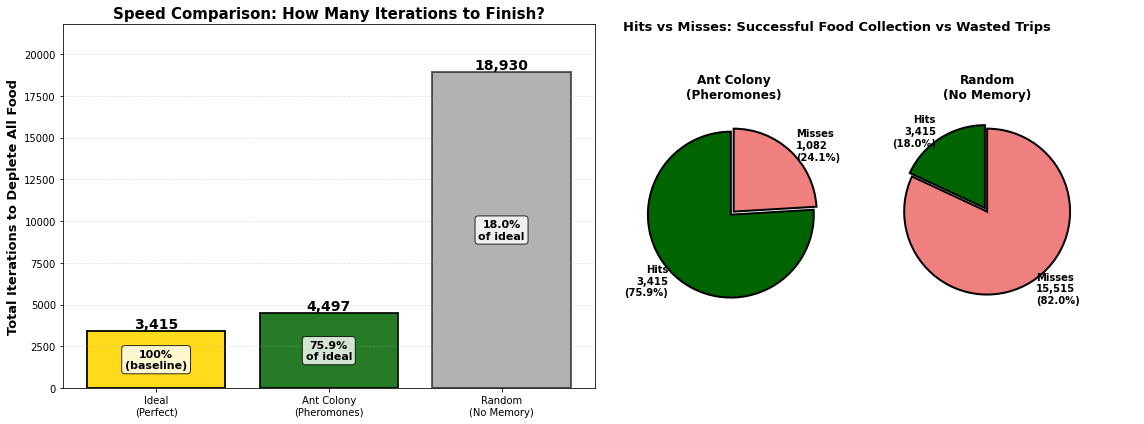


📊 DETAILED BREAKDOWN:
   Ideal:       3,415 iterations (0% waste)
   Ant Colony:  4,497 iterations (24.1% waste)
   Random:      18,930 iterations (82.0% waste)

📊 PROPORTIONAL VISIT ALLOCATION: Are visits distributed according to food availability?

Source   Food       Ideal %      Ant Colony                Random                    Score   
ID       Qty        (Target)     Visits (% of Total)       Visits (% of Total)       (Quality)
------------------------------------------------------------------------------------------------------------------------
F1       436         12.77%      528     (12.80%) ✓    109     ( 9.01%) ↓    0.63  
F2       101          2.96%      194     ( 4.70%) ✓    101     ( 8.35%) ↑    0.56  
F3       311          9.11%      401     ( 9.72%) ✓    89      ( 7.36%) ✓    0.65  
F4       690         20.20%      740     (17.94%) ↓    163     (13.47%) ↓    0.60  
F5       376         11.01%      422     (10.23%) ✓    142     (11.74%) ✓    0.56  
F6       344      

c:\Python\Lib\site-packages\IPython\core\pylabtools.py:152: UserWarning: Glyph 128202 (\N{BAR CHART}) missing from current font.
  fig.canvas.print_figure(bytes_io, **kw)
c:\Python\Lib\site-packages\IPython\core\pylabtools.py:152: UserWarning: Glyph 127919 (\N{DIRECT HIT}) missing from current font.
  fig.canvas.print_figure(bytes_io, **kw)


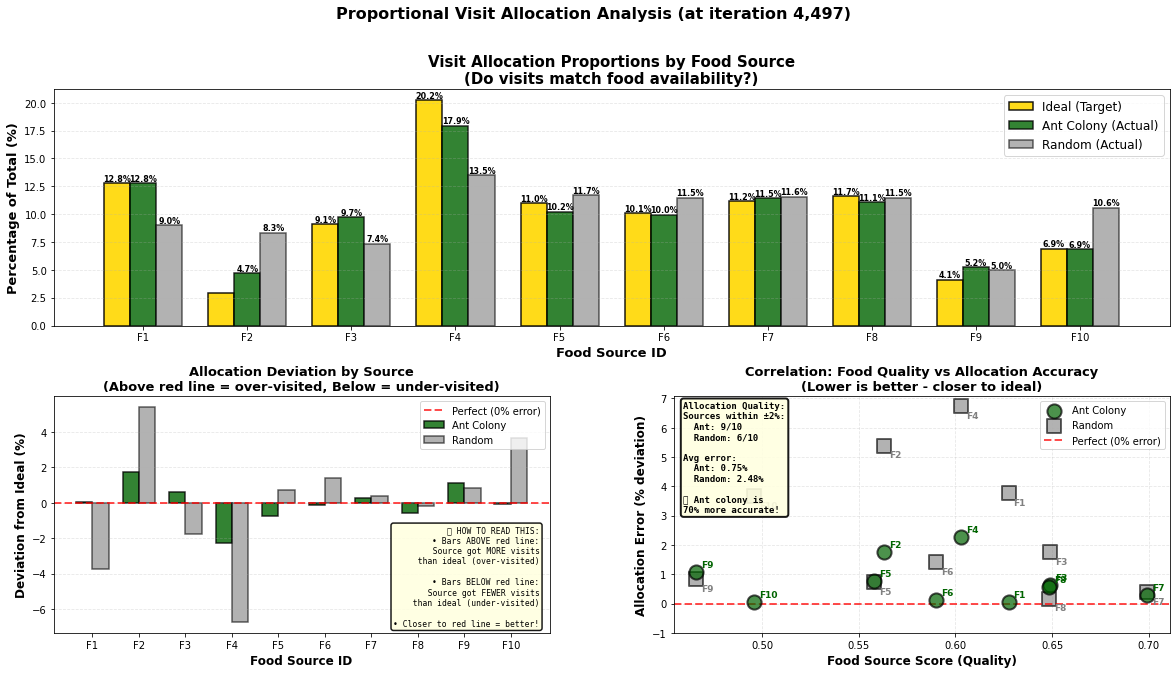


🎯 KEY INSIGHTS:

1. BEST ALLOCATED SOURCES (Ant Colony):
   F1: 0.04% error (ideal: 12.8%, actual: 12.8%)
   F10: 0.05% error (ideal: 6.9%, actual: 6.9%)
   F6: 0.11% error (ideal: 10.1%, actual: 10.0%)

2. WORST ALLOCATED SOURCES (Ant Colony):
   F4: 2.26% error (ideal: 20.2%, actual: 17.9%)
   F2: 1.75% error (ideal: 3.0%, actual: 4.7%)
   F9: 1.08% error (ideal: 4.1%, actual: 5.2%)

3. RANDOM ALLOCATION PATTERN:
   Average visit proportion: 10.00% (should vary by source)
   Standard deviation: 2.42%
   → Random tends toward UNIFORM distribution (bad!)

4. ANT COLONY ALLOCATION PATTERN:
   Correlation with food scores: 0.574
   Correlation with food quantities: 0.993
   → Pheromones create SMART allocation (good!)


In [8]:
# Visualize all results (efficiency + allocation)
sim.visualize_results()

---

## 🎯 Quick Experiments

<details>

<summary style="color:rgb(21, 233, 162); background-color:rgb(9, 0, 0); padding:5px"><b>Try these parameter modifications to see different behaviors: <i style="color:orange">(Click to Expand)</i></b></summary>

<summary></summary>

### Experiment 1: More Scouts
```python
config['scout_frequency'] = 6  # 16.7% scouts instead of 8.3%
```

### Experiment 2: Faster Evaporation
```python
config['evaporation_rate'] = 0.5  # 50% decay instead of 35%
```

### Experiment 3: Smaller Perception
```python
config['ant_perception'] = 2  # 2° instead of 3°
```

### Experiment 4: Equal Weights
```python
config['weight_distance'] = 0.25
config['weight_quality'] = 0.25
config['weight_quantity'] = 0.25
config['weight_ease'] = 0.25
```

### Experiment 5: Steeper Reward Curve
```python
config['reward_exponent'] = 0.8  # More dramatic rewards for good sources
```

### Experiment 6: Reset to Defaults
```python
sim.reset_config()  # Resets all parameters to default values
# Then re-run from "Initialize Simulation" cell
```

**After modifying config, re-run from the "Initialize Simulation" cell!**

</details>